# **02. Business and Statistical Analysis**

In [1]:
import sys
sys.path.append('../src')
from functions import *

import numpy as np
import pandas as pd
import sqlite3
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr


In [2]:
df_sales = pd.read_csv("../data/sales_clean.csv",dtype={"Customer ID": "str"})
df_returns = pd.read_csv("../data/returns_clean.csv",dtype={"Customer ID": "str"})

In [3]:
# create SQLite database
engine = create_engine("sqlite:///../data/retail.db")

# load dataframes
df_sales.to_sql('sales', engine, if_exists='replace', index=False)
df_returns.to_sql('returns', engine, if_exists='replace', index=False)

17915

## 2.1 Revenue distribution

In this first section, we analyze the distribution of revenue across customers and products, with the aim of understanding how the contribution to total revenue is distributed among different entities. Since revenue distributions in retail datasets are often highly concentrated, we investigate this concentration using two complementary measures:

1.    Pareto point: identifies the fraction of customers (or products) responsible for generating a given percentage of total revenue. In this analysis, we focus on the 80/20 rule, measuring the percentage of entities accounting for 80% of the total revenue.

2.    Gini coefficient: provides a quantitative measure of inequality in the revenue distribution. It ranges from 0 (perfect equality, where all customers or products contribute equally) to 1 (maximum inequality, where a single entity accounts for all revenue).

> Note: It was previously observed that some products and customers have a negative net revenue; this is due to a revenue loss from returns higher than the revenue gain from sales, and is probably a consequence of unregistered sales from previous years. For this reason, in this section we only focus on the sales revenue, ignoring revenue loss due to returns.

### 2.1.1 Revenue distribution per customer

In [9]:
q_cust_sal = """
    SELECT SUM(Quantity*Price) AS revenue, "Customer ID"
    FROM sales
    WHERE "Customer ID" IS NOT NULL
    GROUP BY "Customer ID"
    ORDER BY revenue DESC
    """
df_cust_sal = pd.read_sql(q_cust_sal, engine)
df_cust_sal["revenue_pct"] = df_cust_sal["revenue"]/df_cust_sal["revenue"].sum() *100

pareto_point, pareto_revenue, customers_pct = get_pareto(df_cust_sal)

Text(0.5, 1.0, 'Customers Revenue Distribution (log scale, log bins)')

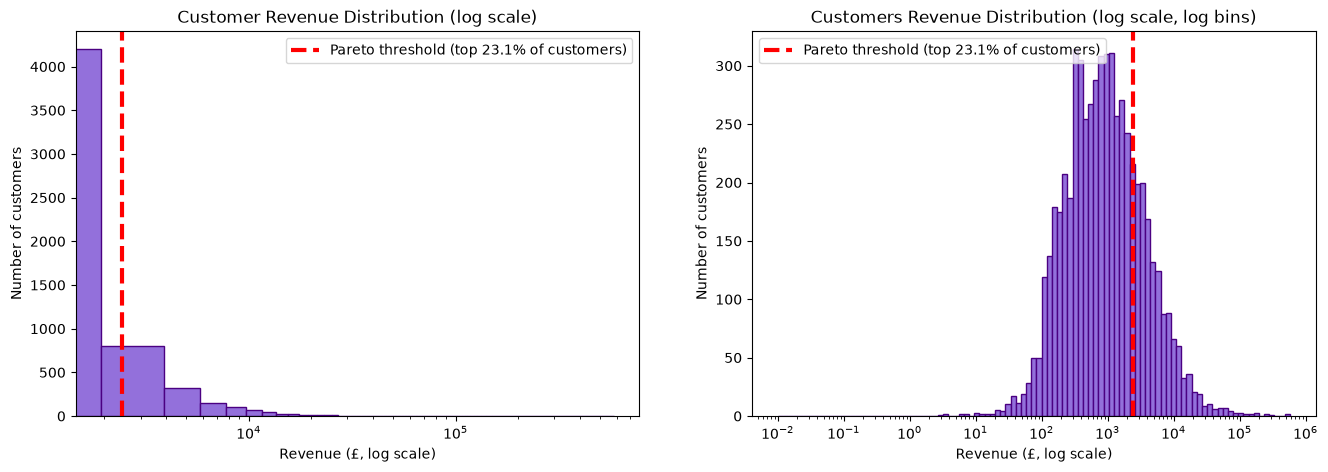

In [10]:
fig,ax = plt.subplots(1,2,figsize=(16,5))

cust_sal_h, bins, _ = ax[0].hist(df_cust_sal["revenue"], bins=300, color="mediumpurple", edgecolor="indigo")
ax[0].set_xscale("log")
ax[0].axvline(x=pareto_revenue, color='red', linestyle='--', label=f'Pareto threshold (top {customers_pct:.1f}% of customers)',linewidth=3)
ax[0].legend()
ax[0].set_xlabel("Revenue (£, log scale)")
ax[0].set_ylabel("Number of customers")
ax[0].set_title("Customer Revenue Distribution (log scale)")

bins_log = np.logspace(np.log10(df_cust_sal["revenue"].min()+0.01), 
                   np.log10(df_cust_sal["revenue"].max()), 
                   100)
cust_sal_hlog = ax[1].hist(df_cust_sal["revenue"], bins=bins_log,color="mediumpurple", edgecolor="indigo" )
ax[1].set_xscale("log")
ax[1].axvline(x=pareto_revenue, color='red', linestyle='--', label=f'Pareto threshold (top {customers_pct:.1f}% of customers)',linewidth=3)
ax[1].legend()
ax[1].set_xlabel("Revenue (£, log scale)")
ax[1].set_ylabel("Number of customers")
ax[1].set_title("Customers Revenue Distribution (log scale, log bins)")

In [8]:
print(f"Mean: £{df_cust_sal['revenue'].mean():,.0f}")
print(f"Median: £{df_cust_sal['revenue'].median():,.0f}")
print(f"Skewness: {df_cust_sal['revenue'].skew():.2f}")

Mean: £2,916
Median: £856
Skewness: 25.33


The revenue distribution is heavily right-skewed, with a skewness of 25.33. This indicates that the majority of customers generate relatively low revenue, making the median a more representative measure of central tendency than the mean. The long right tail suggests that only a small fraction of customers contributes disproportionately to the total revenue.

This observation is consistent with the Pareto analysis: the long right tail corresponds to the 23.1% of customers responsible for 80% of the total revenue.

This pattern can be further quantified using the Gini coefficient.

In [ ]:
gini_customers = gini(df_cust_sal["revenue"].values)
print(f"Gini coefficient (customers): {gini_customers:.3f}")

Gini coefficient (customers): 0.741


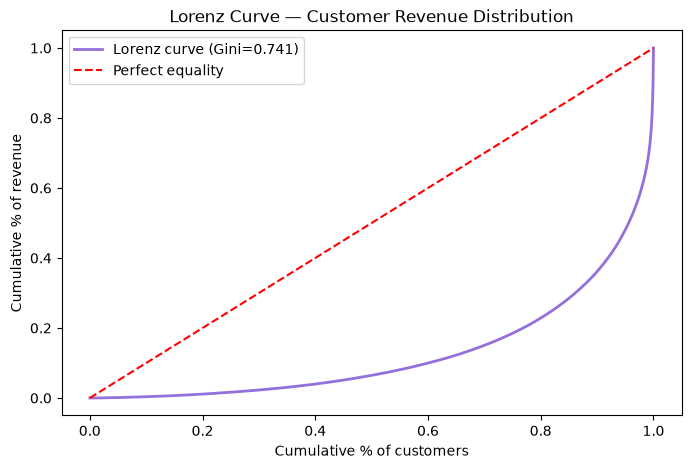

In [ ]:
sorted_rev = np.sort(df_cust_sal["revenue"].values)
cumulative_rev = np.cumsum(sorted_rev) / sorted_rev.sum()
cumulative_pop = np.arange(1, len(sorted_rev) + 1) / len(sorted_rev)

plt.figure(figsize=(8,5))
plt.plot(cumulative_pop, cumulative_rev, label=f'Lorenz curve (Gini={gini_customers:.3f})', c="mediumpurple", linewidth=2)
plt.plot([0, 1], [0, 1], 'r--', label='Perfect equality')
plt.xlabel("Cumulative % of customers")
plt.ylabel("Cumulative % of revenue")
plt.title("Lorenz Curve — Customer Revenue Distribution")
plt.legend()

The Gini coefficient of 0.74 reveals a strong dependence on high-value customers. Combined with the Pareto analysis, this suggests that a relatively small fraction of customers contributes disproportionately to the company's revenue, highlighting the importance of customer retention strategies targeted at these high-value segments.

### 2.1.2 Revenue distribution per product

In [21]:
q_prod_sal = """
    SELECT UPPER(StockCode) as stock_code, Description, SUM(Price*Quantity) as revenue
    FROM sales
    GROUP BY stock_code
    ORDER BY revenue DESC
    """

df_prod_sal = pd.read_sql(q_prod_sal, engine)
df_prod_sal["revenue_pct"] = df_prod_sal["revenue"]/df_prod_sal["revenue"].sum() *100

pareto_point, pareto_revenue, products_pct = get_pareto(df_prod_sal)

Text(0.5, 1.0, 'Products Revenue Distribution (log scale, log bins)')

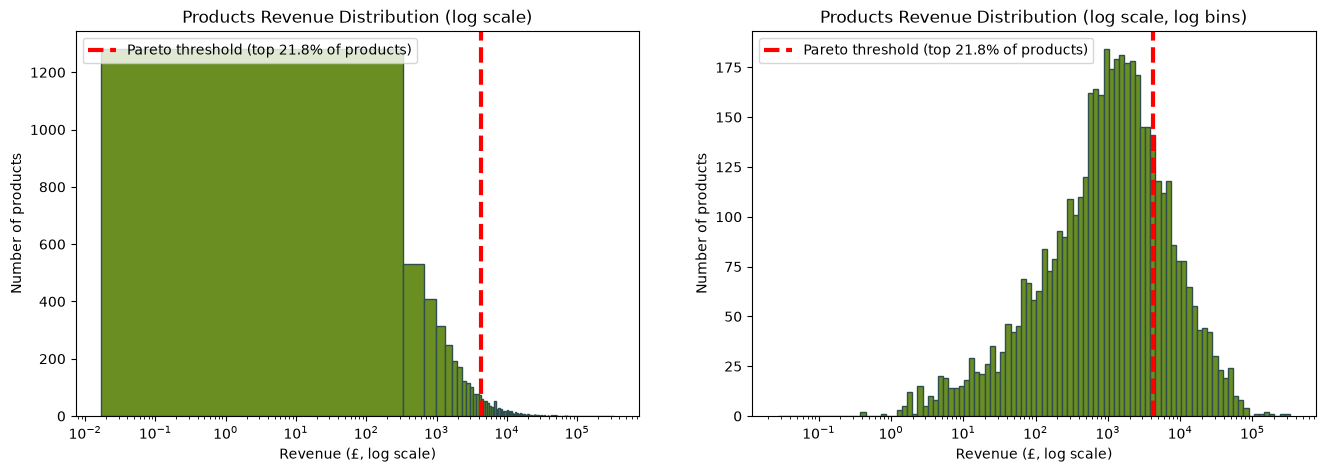

In [26]:
fig,ax = plt.subplots(1,2,figsize=(16,5))

prod_rev_h, bins, _ = ax[0].hist(df_prod_sal["revenue"], bins=1000, color="olivedrab", edgecolor="darkslategrey")
ax[0].axvline(x=pareto_revenue, color='red', linestyle='--', label=f'Pareto threshold (top {products_pct:.1f}% of products)', linewidth = 3)
ax[0].legend()
ax[0].set_xscale("log")
ax[0].set_xlabel("Revenue (£, log scale)")
ax[0].set_ylabel("Number of products")
ax[0].set_title("Products Revenue Distribution (log scale)")


bins_log = np.logspace(np.log10(df_prod_sal["revenue"].min()+0.01), 
                   np.log10(df_prod_sal["revenue"].max()), 
                   100)
prod_rev_hlog = ax[1].hist(df_prod_sal["revenue"], bins=bins_log,color="olivedrab", edgecolor="darkslategrey")
ax[1].set_xscale("log")
ax[1].axvline(x=pareto_revenue, color='red', linestyle='--', label=f'Pareto threshold (top {products_pct:.1f}% of products)', linewidth = 3)
ax[1].legend()
ax[1].set_xlabel("Revenue (£, log scale)")
ax[1].set_ylabel("Number of products")
ax[1].set_title("Products Revenue Distribution (log scale, log bins)")

In [27]:
print(f"Mean: £{df_prod_sal['revenue'].mean():,.0f}")
print(f"Median: £{df_prod_sal['revenue'].median():,.0f}")
print(f"Skewness: {df_prod_sal['revenue'].skew():.2f}")

Mean: £4,157
Median: £1,126
Skewness: 11.99


The revenue distribution by products is also right-skewed, with a skewness of 11.99. This indicates that the majority of products have a relatively low price, and the 21.8% of high-cost products contribute to 80% of the total revenue.   

Let us compute the Gini coefficient:

In [28]:
gini_products = gini(df_prod_sal["revenue"].values)
print(f"Gini coefficient (products): {gini_products:.3f}")

Gini coefficient (products): 0.747


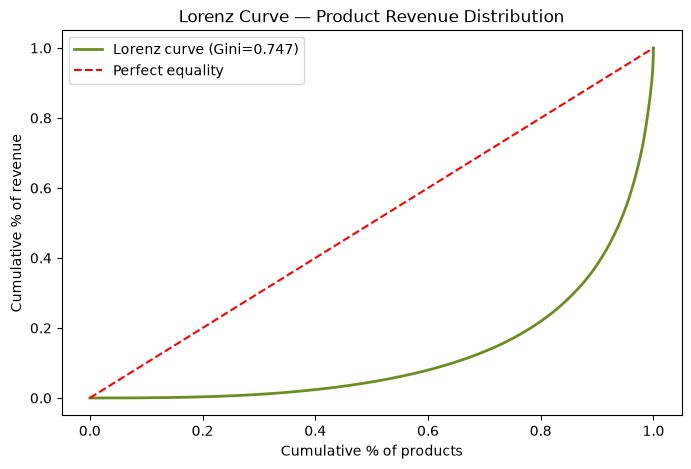

In [29]:
sorted_rev = np.sort(df_prod_sal["revenue"].values)
cumulative_rev = np.cumsum(sorted_rev) / sorted_rev.sum()
cumulative_pop = np.arange(1, len(sorted_rev) + 1) / len(sorted_rev)

plt.figure(figsize=(8,5))
plt.plot(cumulative_pop, cumulative_rev, label=f'Lorenz curve (Gini={gini_products:.3f})', c="olivedrab", linewidth=2)
plt.plot([0, 1], [0, 1], 'r--', label='Perfect equality')
plt.xlabel("Cumulative % of products")
plt.ylabel("Cumulative % of revenue")
plt.title("Lorenz Curve — Product Revenue Distribution")
plt.legend()

The Gini coefficient of 0.75 reveals a strong dependence on high-value customers. Combined with the Pareto analysis, this suggests that a relatively small fraction of products contributes disproportionately to the company's revenue.

## 2.2 Geographic analysis

This section focuses on the geographical analysis of sales, in order to answer the following questions:

1.    Where do most sales come from?

2.    Which country contributes the most to total revenue?     

3.    How are customers distributed across countries?

### 2.2.1 Where do most sales come from?

In [33]:
q_country_vol = """
    SELECT SUM(Quantity) as volume, Country
    FROM sales
    GROUP BY Country
    ORDER BY volume DESC
    """

df_country_vol = pd.read_sql(q_country_vol, engine)
df_country_vol["volume_pct"] = df_country_vol["volume"]/df_country_vol["volume"].sum() *100

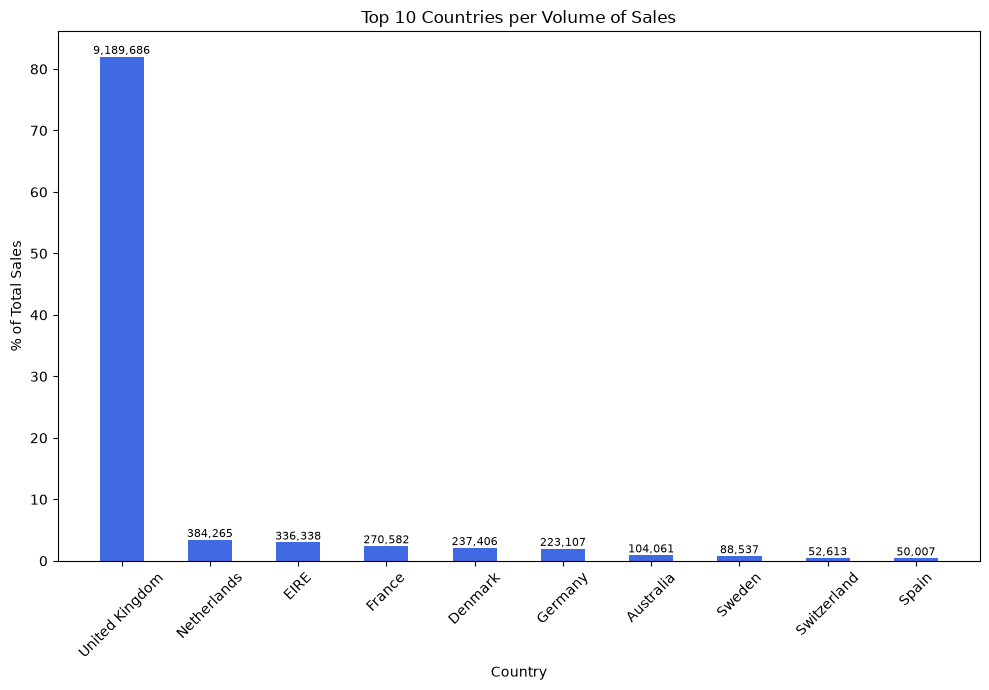

In [34]:
fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.bar(df_country_vol["Country"][:10], 
              df_country_vol["volume_pct"][:10], 
              width=0.5, color="royalblue")

for bar, val in zip(bars, df_country_vol["volume"][:10]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{val:,.0f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xlabel("Country")
ax.set_ylabel("% of Total Sales")
ax.set_title("Top 10 Countries per Volume of Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
uk_vol = df_country_vol[df_country_vol["Country"]=="United Kingdom"]["volume_pct"].item()

print(f"United Kingdom is responsible for {uk_vol:.2f}% of the total volume of sales.")

United Kingdom is responsible for 82.03% of the total volume of sales.


### 2.2.2 Which Country contributes the most to total revenue?

In [36]:
q_country_net_rev = """
    SELECT SUM(Price*Quantity) AS revenue, Country
    FROM (SELECT Country, Price, Quantity FROM sales
        UNION ALL
        SELECT Country, Price, Quantity FROM returns
        )
    GROUP BY Country
    ORDER BY revenue DESC
    """

df_country_net_rev = pd.read_sql(q_country_net_rev, engine)
df_country_net_rev["revenue_pct"]=df_country_net_rev["revenue"]/(df_country_net_rev["revenue"].sum())*100

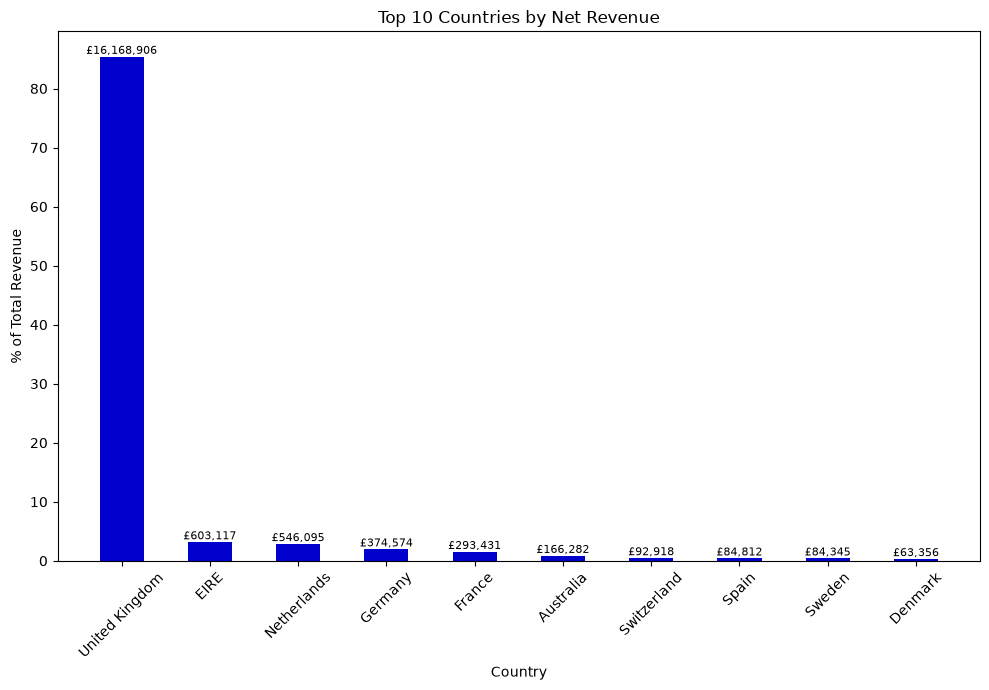

In [39]:
fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.bar(df_country_net_rev["Country"][:10], 
              df_country_net_rev["revenue_pct"][:10], 
              width=0.5, color="mediumblue")

for bar, val in zip(bars, df_country_net_rev["revenue"][:10]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'£{val:,.0f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xlabel("Country")
ax.set_ylabel("% of Total Revenue")
ax.set_title("Top 10 Countries by Net Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
uk_rev = df_country_net_rev[df_country_net_rev["Country"]=="United Kingdom"]["revenue_pct"].item()

print(f"United Kingdom is responsible for {uk_rev:.2f}% of the total revenue.")

United Kingdom is responsible for 85.43% of the total revenue.


### 2.2.3 How are customers distributed across countries?

In [40]:
q_cust_country = """
    SELECT COUNT(*) AS customers, Country
    FROM sales
    WHERE "Customer ID" IS NOT NULL
    GROUP BY Country
    ORDER BY customers DESC
    """
df_cust_country = pd.read_sql(q_cust_country, engine)
df_cust_country["customers_pct"] = df_cust_country["customers"]/df_cust_country["customers"].sum() * 100

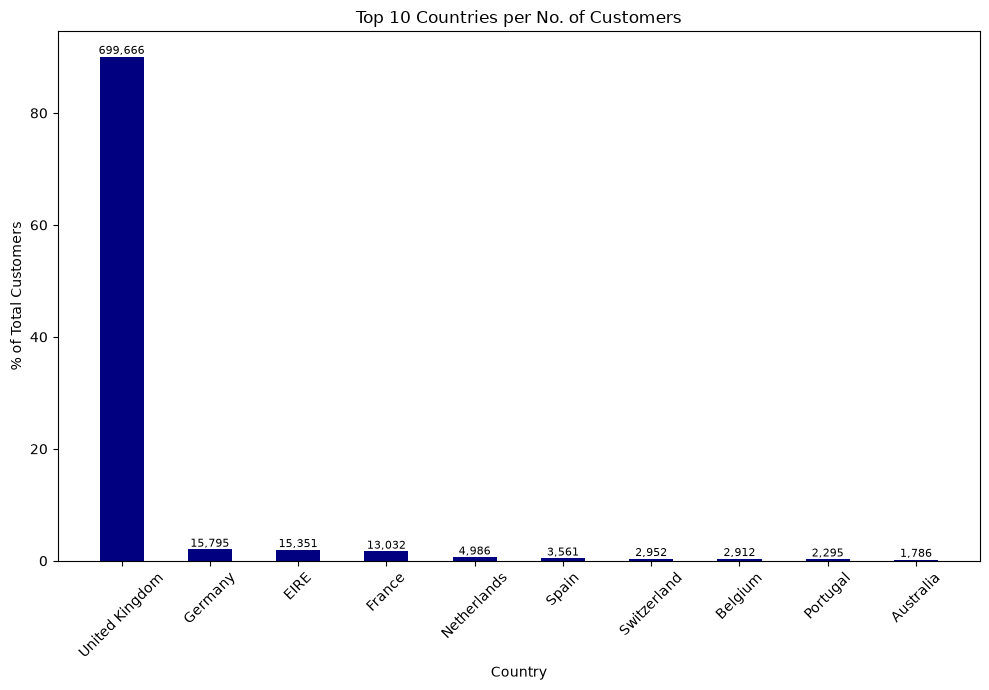

In [41]:
fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.bar(df_cust_country["Country"][:10], 
              df_cust_country["customers_pct"][:10], 
              width=0.5, color="navy")

for bar, val in zip(bars, df_cust_country["customers"][:10]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{val:,.0f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xlabel("Country")
ax.set_ylabel("% of Total Customers")
ax.set_title("Top 10 Countries per No. of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
uk_cust = df_cust_country[df_cust_country["Country"]=="United Kingdom"]["customers_pct"].item()
print(f"{uk_cust:.2f}% of customers come from the United Kingdom.")

90.09% of customers come from the United Kingdom.


The geographical analysis tells a clear story: most of the contribution to the company's sales and revenue comes from the UK, which constitutes 90.09% of the customerbase.    
UK customers account for 85.34% of the total revenue and 82.03% of total sales.

## 2.3 Sales seasonality

In this section, we investigate the temporal dynamics of the business by analyzing the seasonality of revenue and sales volume. The objective is to identify recurring patterns in demand and understand whether specific periods of the year consistently generate higher sales activity.    
In regards to revenue, we will observe the temporal behaviour of both the sales revenue and net revenue (accountig for returns).


Both monthly and quarterly aggregations are considered to capture different levels of seasonality and evaluate the contribution of each period to the overall yearly performance.

### 2.3.1 Monthly trends

In [45]:
q_net_revenue = """
    SELECT strftime('%Y-%m', InvoiceDate) AS year_month, SUM(Price*Quantity) AS revenue
    FROM (SELECT InvoiceDate, Price, Quantity FROM sales
        UNION ALL
        SELECT InvoiceDate, Price, Quantity FROM returns
        )
    GROUP BY year_month
    ORDER BY year_month
    """

q_sales = """
    SELECT strftime('%Y-%m', InvoiceDate) AS year_month, SUM(Price*Quantity) AS revenue
    FROM sales
    GROUP BY year_month
    ORDER BY year_month
    """

q_sal_vol = """
    SELECT strftime('%Y-%m', InvoiceDate) AS year_month, SUM(Quantity) AS volume
    FROM sales
    GROUP BY year_month
    ORDER BY year_month
    """

df_net_rev = pd.read_sql(q_net_revenue,engine) # Net revenue
df_sal_rev = pd.read_sql(q_sales,engine)   # Sales revenue
df_sal_vol = pd.read_sql(q_sal_vol,engine)   # Sales volume

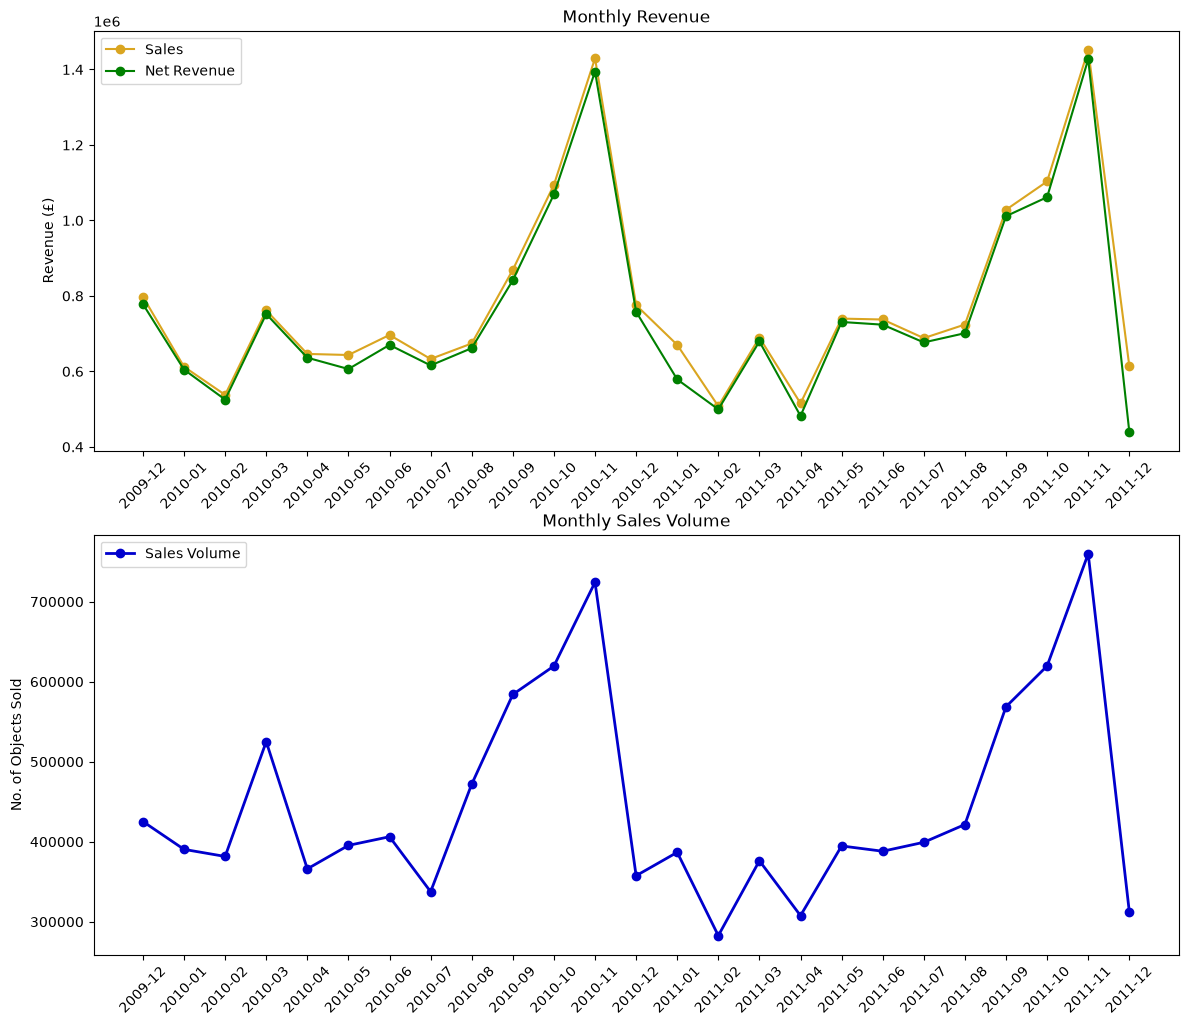

In [53]:
# Plot results
fig, ax =plt.subplots(2,1,figsize=(14,12))

ax[0].plot(df_sal_rev["year_month"], df_sal_rev["revenue"],c="goldenrod", label="Sales", marker='o')
ax[0].plot(df_net_rev["year_month"], df_net_rev["revenue"],c="green", label="Net Revenue", marker='o')
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_title("Monthly Revenue")
ax[0].set_ylabel("Revenue (£)")
ax[0].legend()

ax[1].plot(df_sal_vol["year_month"], df_sal_vol["volume"],c="mediumblue",linewidth=2, label="Sales Volume", marker='o')
ax[1].tick_params(axis='x', rotation=45)
ax[1].set_title("Monthly Sales Volume")
ax[1].set_ylabel("No. of Objects Sold")
ax[1].legend()

### 2.3.2 Quarterly trends

For the quarterly trends, the year 2009 is not considered since the only available data for that specific year refers to December.

In [54]:
q_net_rev_quart = """
    SELECT SUM(Price*Quantity) AS revenue, strftime('%Y', InvoiceDate) AS year,
    CASE
        WHEN strftime('%m', InvoiceDate) IN ('01','02','03') THEN 'Q1'
        WHEN strftime('%m', InvoiceDate) IN ('04','05','06') THEN 'Q2'
        WHEN strftime('%m', InvoiceDate) IN ('07','08','09') THEN 'Q3'
        WHEN strftime('%m', InvoiceDate) IN ('10','11','12') THEN 'Q4'
    END AS quarter
    FROM (SELECT InvoiceDate, Price, Quantity FROM sales
        UNION ALL
        SELECT InvoiceDate, Price, Quantity FROM returns
        )
    WHERE year!='2009'
    GROUP BY year, quarter
    """

q_sal_rev_quart = """
    SELECT SUM(Price*Quantity) AS revenue, strftime('%Y', InvoiceDate) AS year,
    CASE
        WHEN strftime('%m', InvoiceDate) IN ('01','02','03') THEN 'Q1'
        WHEN strftime('%m', InvoiceDate) IN ('04','05','06') THEN 'Q2'
        WHEN strftime('%m', InvoiceDate) IN ('07','08','09') THEN 'Q3'
        WHEN strftime('%m', InvoiceDate) IN ('10','11','12') THEN 'Q4'
    END AS quarter
    FROM sales
    WHERE year!='2009'
    GROUP BY year, quarter
    """

q_vol_quart = """
    SELECT SUM(Quantity) AS volume, strftime('%Y', InvoiceDate) AS year,
    CASE
        WHEN strftime('%m', InvoiceDate) IN ('01','02','03') THEN 'Q1'
        WHEN strftime('%m', InvoiceDate) IN ('04','05','06') THEN 'Q2'
        WHEN strftime('%m', InvoiceDate) IN ('07','08','09') THEN 'Q3'
        WHEN strftime('%m', InvoiceDate) IN ('10','11','12') THEN 'Q4'
    END AS quarter
    FROM sales
    WHERE year!='2009'
    GROUP BY year, quarter
    """


df_net_rev_quart = pd.read_sql(q_net_rev_quart,engine)
df_sal_rev_quart = pd.read_sql(q_sal_rev_quart,engine)
df_sal_quart = pd.read_sql(q_vol_quart,engine)

df_net_rev_quart["year_quarter"] = df_net_rev_quart["year"] + "-" + df_net_rev_quart["quarter"]
df_sal_rev_quart["year_quarter"] = df_sal_rev_quart["year"] + "-" + df_sal_rev_quart["quarter"]
df_sal_quart["year_quarter"] = df_sal_quart["year"] + "-" + df_sal_quart["quarter"]

Text(0, 0.5, 'No. of Objects Sold')

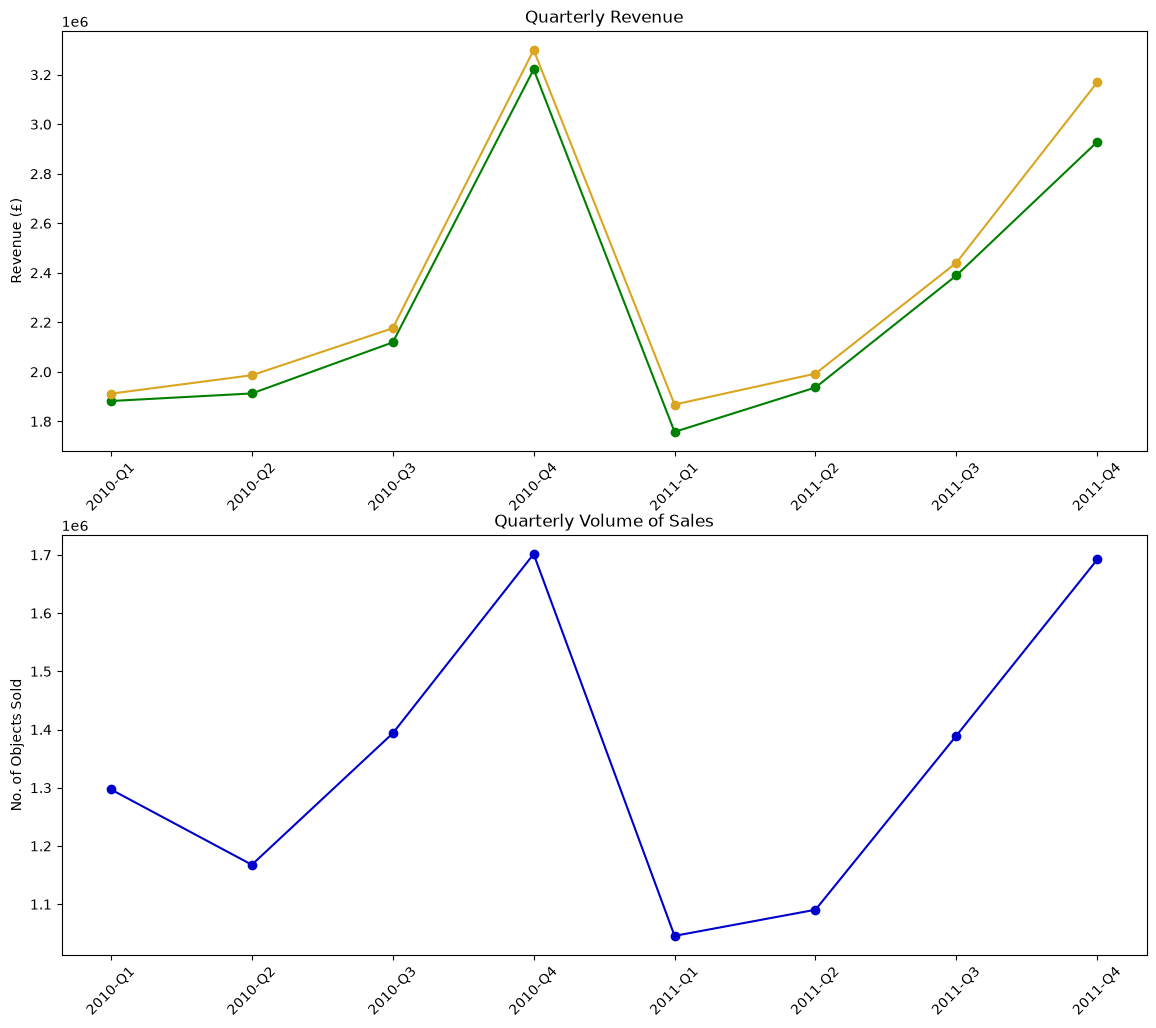

In [56]:
fig, ax = plt.subplots(2,1,figsize=(14,12))

ax[0].plot(df_net_rev_quart["year_quarter"], df_net_rev_quart["revenue"],c="green", marker='o', label="Net Revenue")
ax[0].plot(df_sal_rev_quart["year_quarter"], df_sal_rev_quart["revenue"],c="goldenrod", marker='o', label="Sales Revenue")
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_title("Quarterly Revenue")
ax[0].set_ylabel("Revenue (£)")

ax[1].plot(df_sal_quart["year_quarter"], df_sal_quart["volume"],c="mediumblue", marker='o')
ax[1].tick_params(axis='x', rotation=45)
ax[1].set_title("Quarterly Volume of Sales")
ax[1].set_ylabel("No. of Objects Sold")

From these trends, we can draw two main observations:

1.    Sales volume and revenue exhibit similar temporal patterns, suggesting that periods with higher purchasing activity are generally associated with higher revenue generation.

2.   A consistent increase in both sales volume and revenue can be observed around November and December of each year, with Q4 representing the strongest performing period. This pattern is consistent with the so-called "holiday effect", where consumer spending typically increases during the Christmas shopping period.

### 2.3.3 Average Order Value

The previous results suggest that fluctuations in purchasing activity are the main driver of revenue variations.   
It might be now interesting to investigate whether the higher revenue observed in high-sales period is the result of a higher number of orders placed or a higher value of each single order. 
To do so, we can analyze the trends in number of transactions and in average order value, defined as: $$AOV=\dfrac{\text{Net revenue}}{\text{Number of Transactions}}$$

In [68]:
q_aov_quart = """
    SELECT COUNT(DISTINCT Invoice) AS transactions, SUM(Quantity*Price) AS revenue, strftime('%Y', InvoiceDate) AS year,
    CASE
        WHEN strftime('%m', InvoiceDate) IN ('01','02','03') THEN 'Q1'
        WHEN strftime('%m', InvoiceDate) IN ('04','05','06') THEN 'Q2'
        WHEN strftime('%m', InvoiceDate) IN ('07','08','09') THEN 'Q3'
        WHEN strftime('%m', InvoiceDate) IN ('10','11','12') THEN 'Q4'
    END AS quarter
    FROM (SELECT InvoiceDate, Invoice, Price, Quantity FROM sales
        UNION ALL
        SELECT InvoiceDate, Invoice, Price, Quantity FROM returns
        )
    WHERE year!='2009'
    GROUP BY year, quarter
    """
df_aov_quart = pd.read_sql(q_aov_quart, engine)
df_aov_quart["year_quarter"] = df_aov_quart["year"] + "-" + df_aov_quart["quarter"]


Text(0, 0.5, 'Average Order Value')

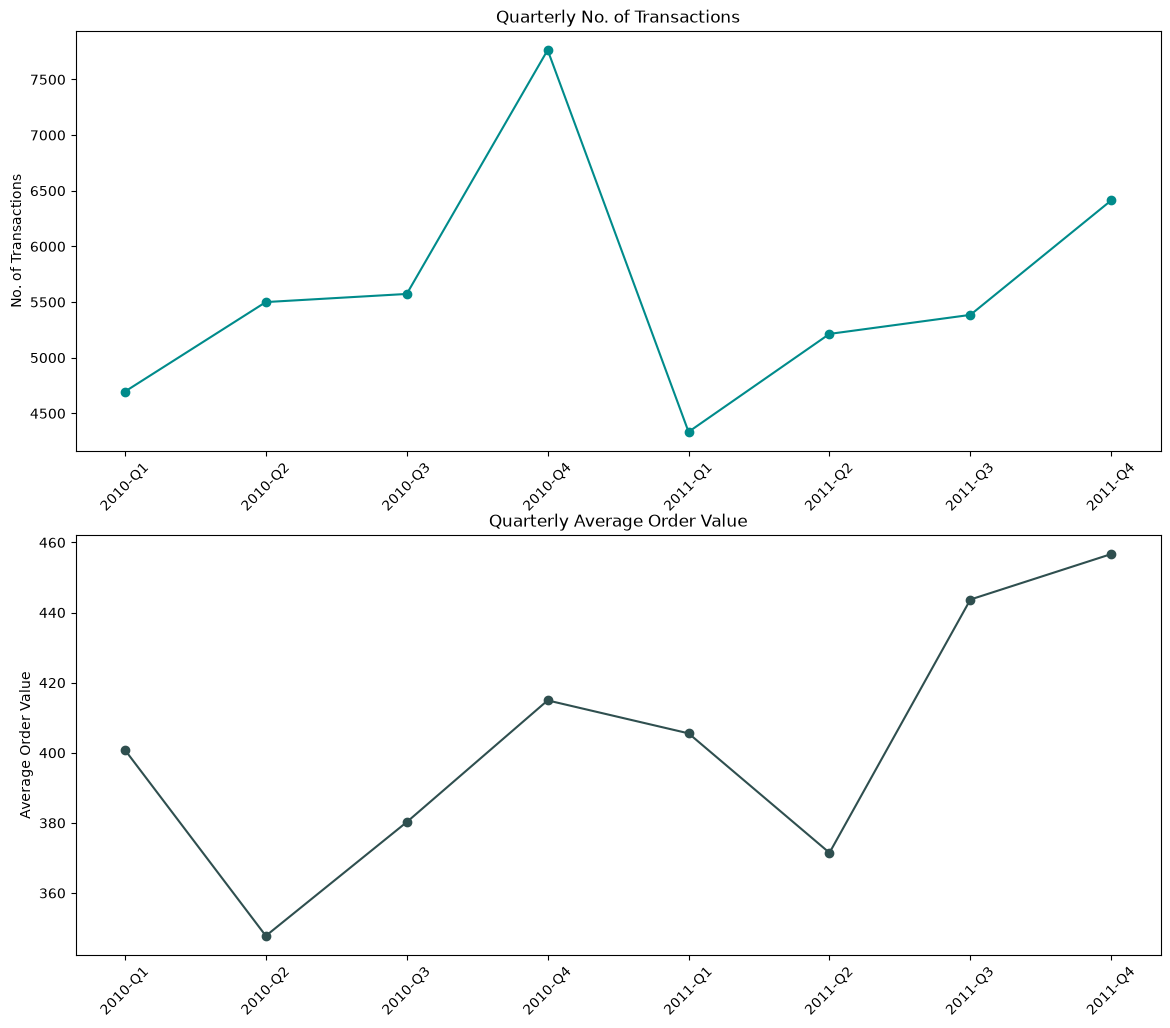

In [75]:
fig, ax = plt.subplots(2,1,figsize=(14,12))

ax[0].plot(df_aov_quart["year_quarter"], df_aov_quart["transactions"],c="darkcyan", marker='o')
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_title("Quarterly No. of Transactions")
ax[0].set_ylabel("No. of Transactions")

ax[1].plot(df_aov_quart["year_quarter"], df_aov_quart["revenue"]/df_aov_quart["transactions"],c="darkslategray", marker='o')
ax[1].tick_params(axis='x', rotation=45)
ax[1].set_title("Quarterly Average Order Value")
ax[1].set_ylabel("Average Order Value")

The quarterly trends of the number of transactions and the Average Order Value (AOV) provide additional insight into the seasonal increase in revenue observed during Q4. In both years, the number of transactions reaches its highest level during the last quarter, indicating that more purchase orders are placed during the holiday season. At the same time, the AOV also increases, suggesting that customers tend to spend more on each order. Therefore, the Q4 revenue peak appears to be driven by the combined effect of an increased purchasing activity and a higher average value per transaction.

## 2.4 Product performance

This section focuses on product performance by analyzing both sales volume and net revenue. Although products with higher sales volumes are generally expected to generate higher revenue, differences in unit price may lead to substantially different rankings.    
Comparing products from these two perspectives allows us to identify the relationship between popularity and economic impact, highlighting whether the best-selling products are also the main revenue generators.

### 2.4.1 Which products sell the most?

In [82]:
q_prod = """
    SELECT UPPER(StockCode) as stock_code, Description, SUM(CASE WHEN Quantity > 0 THEN Quantity ELSE 0 END) as volume, SUM(Price*Quantity) as revenue
    FROM (SELECT StockCode, Description, Price, Quantity FROM sales
        UNION ALL
        SELECT StockCode, Description, Price, Quantity FROM returns
        )
    GROUP BY stock_code
    ORDER BY volume DESC
    """
df_prod = pd.read_sql(q_prod, engine)
df_prod["volume_pct"] = df_prod["volume"]/df_prod["volume"].sum() *100
df_prod["revenue_pct"] = df_prod["revenue"]/df_prod["revenue"].sum() *100


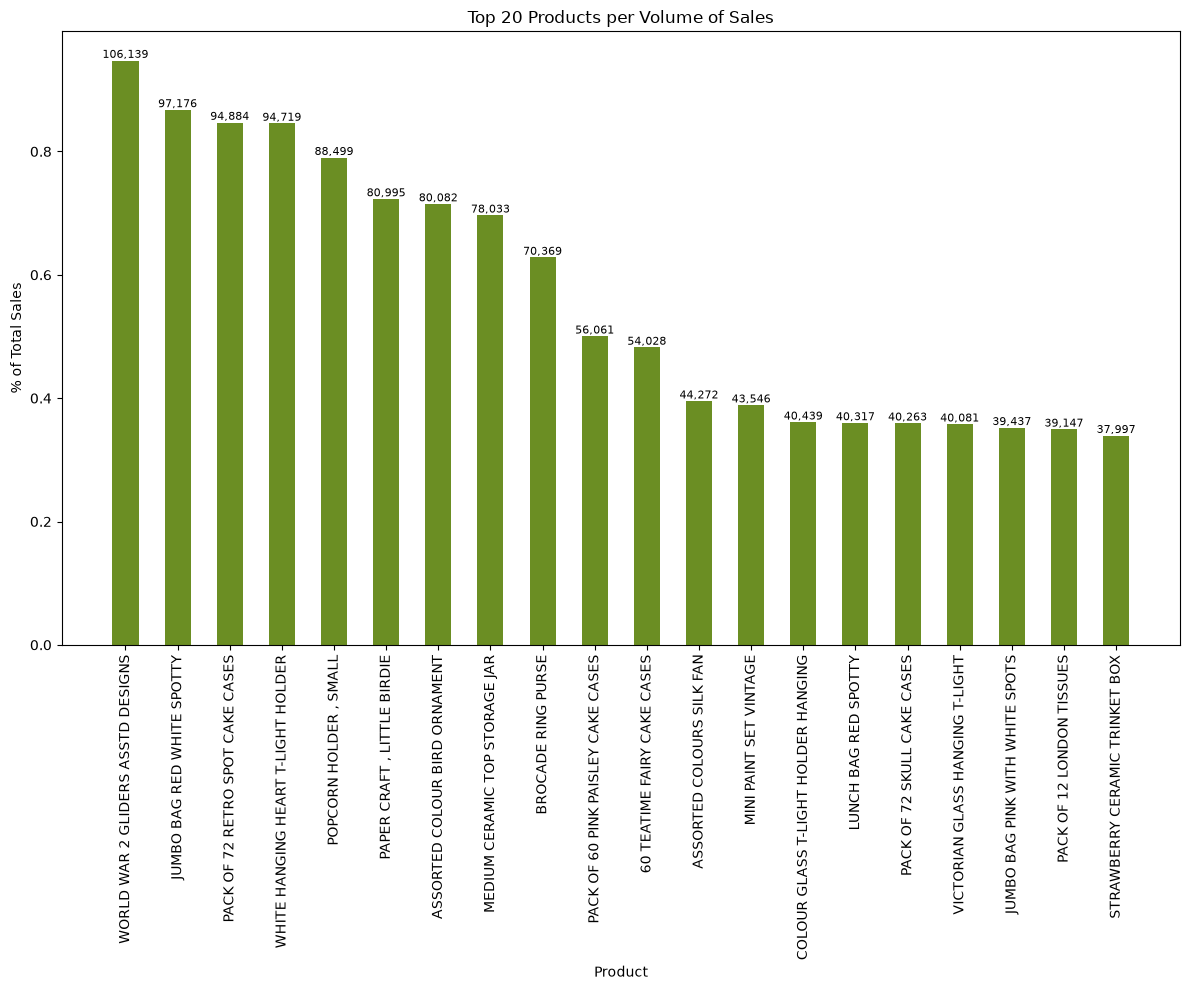

In [83]:
fig, ax = plt.subplots(figsize=(12, 10))

bars = ax.bar(df_prod["Description"][:20], 
              df_prod["volume_pct"][:20], 
              width=0.5, color="olivedrab")

for bar, val in zip(bars, df_prod["volume"][:20]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{val:,.0f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xlabel("Product")
ax.set_ylabel("% of Total Sales")
ax.set_title("Top 20 Products per Volume of Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 2.4.2 Which products generate the most revenue?

In [85]:
df_prod.sort_values(by=["revenue"], ascending=False, inplace=True)

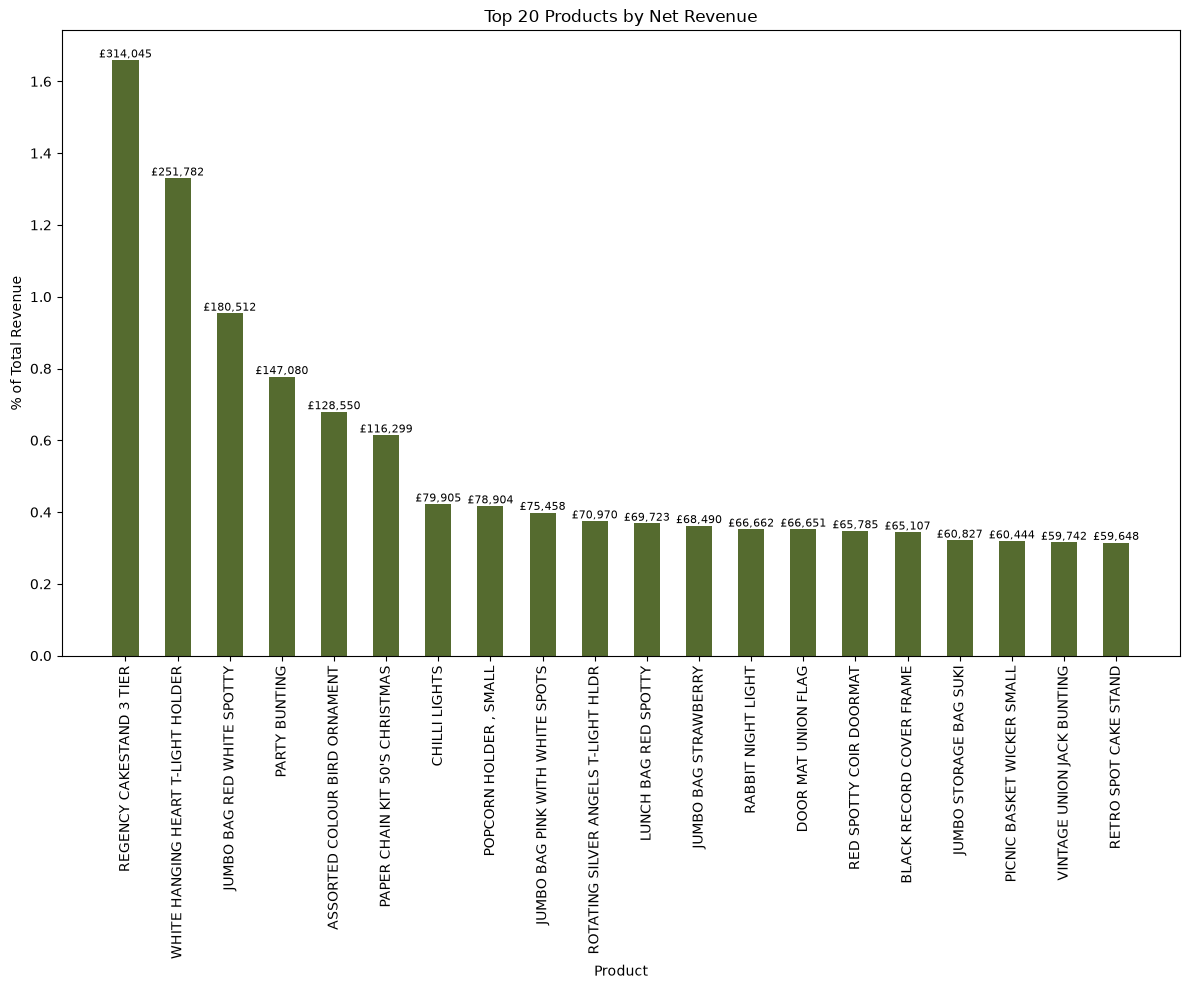

In [86]:
fig, ax = plt.subplots(figsize=(12, 10))

bars = ax.bar(df_prod["Description"][:20], 
              df_prod["revenue_pct"][:20], 
              width=0.5, color="darkolivegreen")

for bar, val in zip(bars, df_prod["revenue"][:20]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'£{val:,.0f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xlabel("Product")
ax.set_ylabel("% of Total Revenue")
ax.set_title("Top 20 Products by Net Revenue")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 2.4.3 Best-sellers VS Best revenue generators

While several products appear in both the top-20 revenue and volume rankings, others are exclusive to one of them, suggesting that popularity and revenue generation are not perfectly aligned.    
We now investigate on the correlation between best-selling products and best revenue generators, by employing the Spearman correlation coefficient, that measures monotonic relationship between two non normally distributed variables.

In [101]:
r = spearmanr(df_prod["volume"], df_prod["revenue"])
print(f"Spearman coefficient: {r.statistic:.3f}, p-value: {r.pvalue}")

Spearman coefficient: 0.842, p-value: 0.0


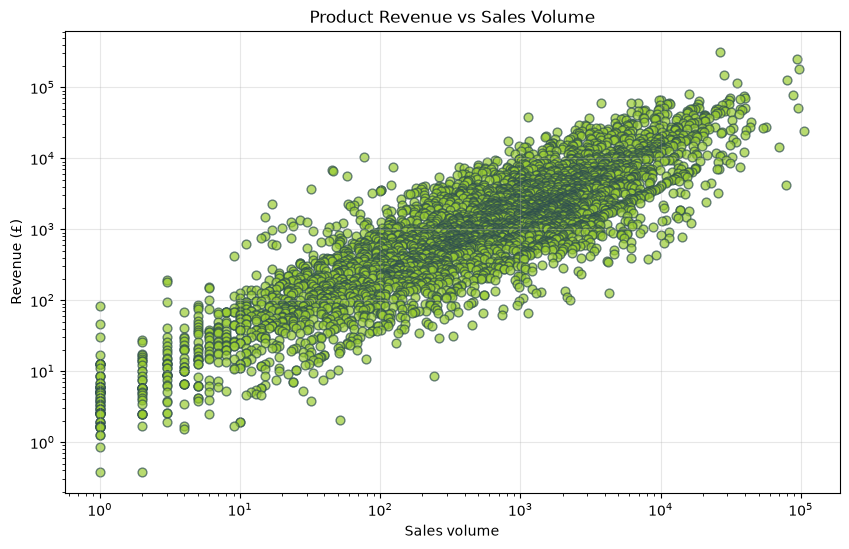

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(
    df_prod["volume"],
    df_prod["revenue"],
    color="yellowgreen",
    alpha=0.7,
    edgecolor="darkslategrey",
    s=40)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Sales volume")
plt.ylabel("Revenue (£)")
plt.title("Product Revenue vs Sales Volume")
plt.grid(alpha=0.3)

The Spearman correlation coefficient between sales volume and net revenue across products is 0.84, indicating a strong monotonic relationship. While a positive correlation is expected — products that sell more naturally tend to generate more revenue — the high magnitude of this coefficient suggests that there are no significant exceptions to this pattern: products with high sales volume consistently rank high in revenue contribution as well, and vice versa.

## 2.5 Returns

This section focuses on the analysis of return rates, with the aim of understanding temporal trends in returns as well as investigate possible causes for returns

### 2.5.1 Temporal return rates

For the temporal analysis of returns we will monitor both the return and the returns rate i.e. the percentage of returns over total sales.    

While they might be similar in trend, the return rate can be more informative than the absolute number of returns, as it relates the returns with the total number of sales. Although a higher absolute number of returns could indicate issues with a specific product or with the company in a certain period, it might as well be naturally caused by the higher amount of sales: identifying which is the case becomes much simpler if we monitor the return rate.       

In [78]:
q_ret_month = """
    SELECT s.year_month, s.sales_volume,
    COALESCE(r.return_volume, 0) AS return_volume,
    ROUND(COALESCE(r.return_volume, 0) * 100.0 / s.sales_volume, 2) AS return_rate
    FROM (
        SELECT strftime('%Y-%m', InvoiceDate) as year_month, SUM(Quantity) AS sales_volume 
        FROM sales 
        GROUP BY year_month
    ) s
    LEFT JOIN (
        SELECT strftime('%Y-%m', InvoiceDate) as year_month, SUM(ABS(Quantity)) AS return_volume 
        FROM returns 
        GROUP BY year_month
    ) r ON s.year_month = r.year_month

    ORDER BY s.year_month
    """


q_ret_quart = """
    SELECT s.year, s.quarter, s.sales_volume,
    COALESCE(r.return_volume, 0) AS return_volume,
    ROUND(COALESCE(r.return_volume, 0) * 100.0 / s.sales_volume, 2) AS return_rate
    FROM (
        SELECT SUM(Quantity) AS sales_volume, strftime('%Y', InvoiceDate) as year,
        CASE
            WHEN strftime('%m', InvoiceDate) IN ('01','02','03') THEN 'Q1'
            WHEN strftime('%m', InvoiceDate) IN ('04','05','06') THEN 'Q2'
            WHEN strftime('%m', InvoiceDate) IN ('07','08','09') THEN 'Q3'
            WHEN strftime('%m', InvoiceDate) IN ('10','11','12') THEN 'Q4'
        END AS quarter
        FROM sales 
        WHERE year!='2009'
        GROUP BY year, quarter
    ) s
    LEFT JOIN (
        SELECT SUM(ABS(Quantity)) AS return_volume, strftime('%Y', InvoiceDate) as year,
        CASE
            WHEN strftime('%m', InvoiceDate) IN ('01','02','03') THEN 'Q1'
            WHEN strftime('%m', InvoiceDate) IN ('04','05','06') THEN 'Q2'
            WHEN strftime('%m', InvoiceDate) IN ('07','08','09') THEN 'Q3'
            WHEN strftime('%m', InvoiceDate) IN ('10','11','12') THEN 'Q4'
        END AS quarter
        FROM returns
        WHERE year!='2009'
        GROUP BY year, quarter
    ) r ON s.year = r.year AND s.quarter = r.quarter
    ORDER BY s.year, s.quarter
    """

df_ret_month = pd.read_sql(q_ret_month,engine)
df_ret_quart = pd.read_sql(q_ret_quart,engine)
df_ret_quart["year_quarter"] = df_ret_quart["year"] + "-" + df_ret_quart["quarter"]   

Text(0, 0.5, 'Return Rate (%)')

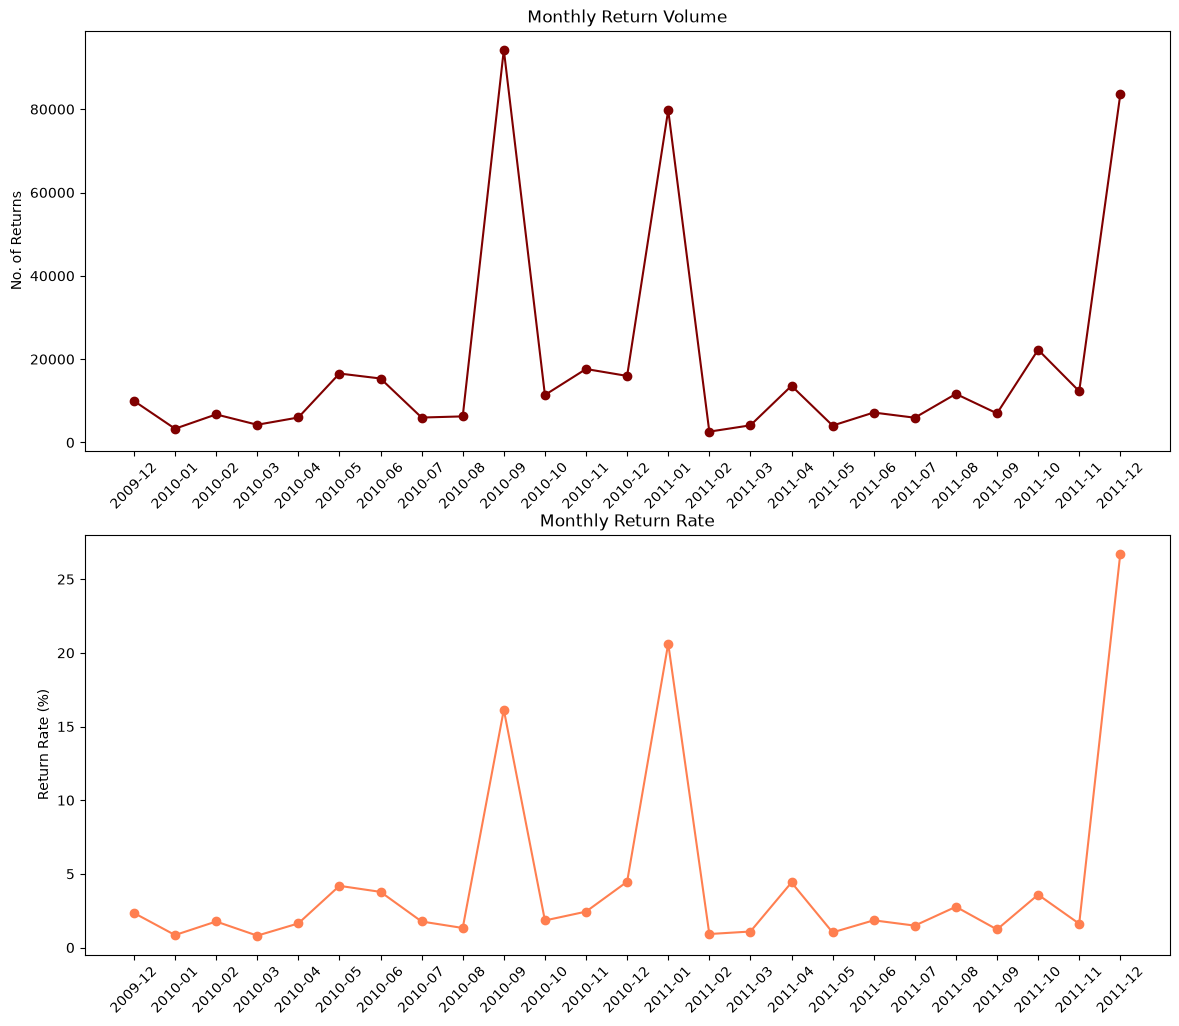

In [79]:
fig, ax = plt.subplots(2,1,figsize=(14,12))
ax[0].plot(df_ret_month["year_month"], df_ret_month["return_volume"],c="maroon", marker='o')
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_title("Monthly Return Volume")
ax[0].set_ylabel("No. of Returns")

ax[1].plot(df_ret_month["year_month"], df_ret_month["return_rate"],c="coral", marker='o')
ax[1].tick_params(axis='x', rotation=45)
ax[1].set_title("Monthly Return Rate")
ax[1].set_ylabel("Return Rate (%)")


Text(0, 0.5, 'Return Rate (%)')

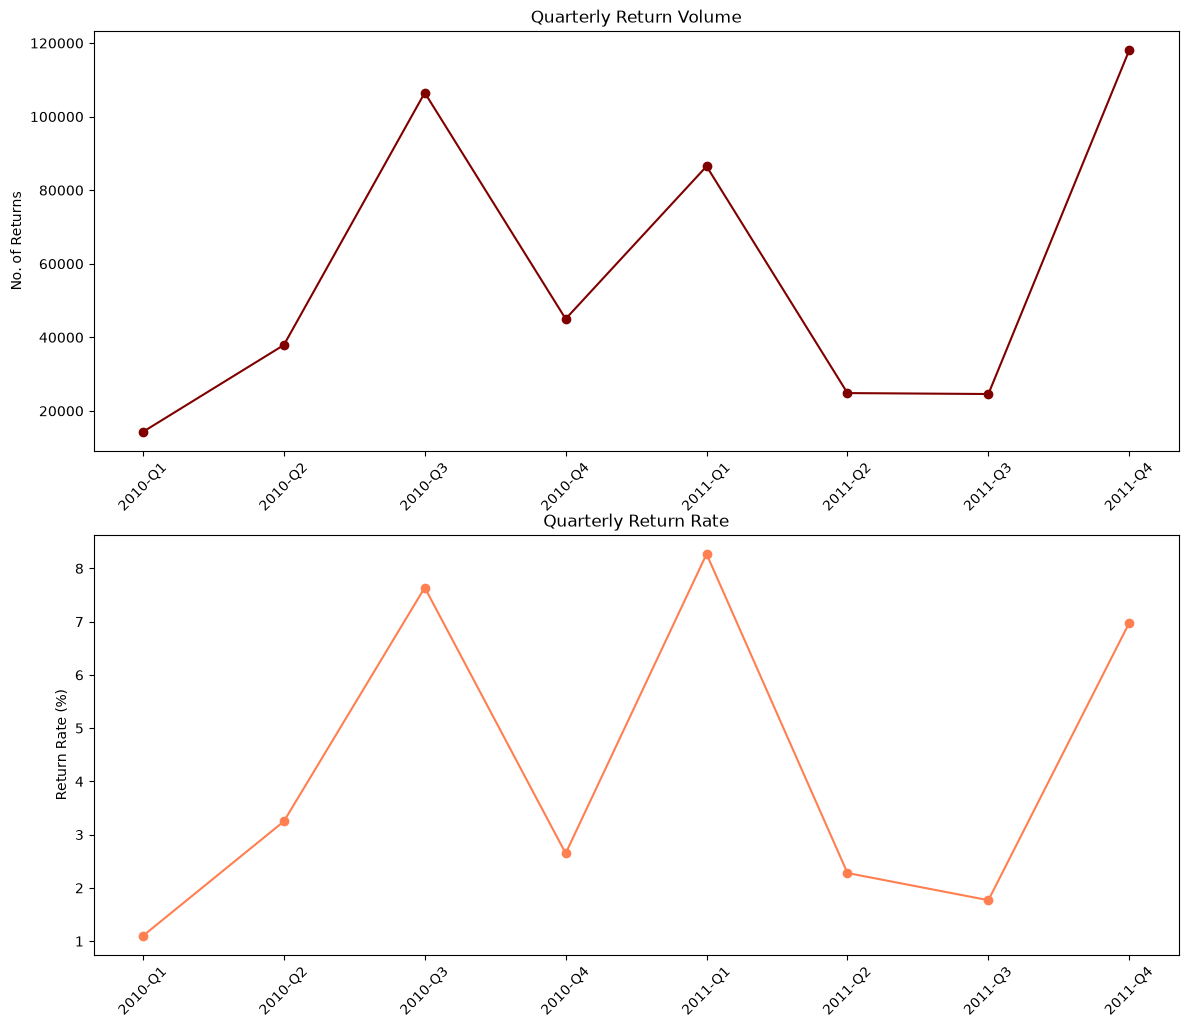

In [80]:
fig, ax = plt.subplots(2,1,figsize=(14,12))
ax[0].plot(df_ret_quart["year_quarter"], df_ret_quart["return_volume"],c="maroon", marker='o')
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_title("Quarterly Return Volume")
ax[0].set_ylabel("No. of Returns")

ax[1].plot(df_ret_quart["year_quarter"], df_ret_quart["return_rate"],c="coral", marker='o')
ax[1].tick_params(axis='x', rotation=45)
ax[1].set_title("Quarterly Return Rate")
ax[1].set_ylabel("Return Rate (%)")

Both monthly and quarterly, the trend in volume of returns overall aligns with the trend in return rate, indicating that the number of sales is strongly related to the absolute number of returns.    
Noticeable peaks in returns can be observed in September of 2010, January of 2011 and December of 2011.

In [7]:
avg_return_rate = df_ret_month["return_rate"].mean()
min_return_rate = df_ret_month["return_rate"].min()
max_return_rate = df_ret_month["return_rate"].max()

avg_ret_rate_nopeaks = df_ret_month[(df_ret_month["year_month"]!="2010-09") & (df_ret_month["year_month"]!="2011-01") & (df_ret_month["year_month"]!="2011-12")]["return_rate"].mean()
return_rate_peak1 = df_ret_month[df_ret_month["year_month"]=="2010-09"]["return_rate"].item()
return_rate_peak2 = df_ret_month[df_ret_month["year_month"]=="2011-01"]["return_rate"].item()
return_rate_peak3 = df_ret_month[df_ret_month["year_month"]=="2011-12"]["return_rate"].item()

print(f"The monthly return rate lies in the range {min_return_rate:.2f}%-{max_return_rate:.2f}%, with average at {avg_return_rate:.2f}%.")
print(f"Noticeable outliers: {return_rate_peak1:.2f}% (2010-09),  {return_rate_peak2:.2f}% (2011-01),  {return_rate_peak3:.2f}% (2011-12)")
print(f"Average return rate excluding outliers: {avg_ret_rate_nopeaks:.2f}%")

The monthly return rate lies in the range 0.81%-26.72%, with average at 4.43%.
Noticeable outliers: 16.14% (2010-09),  20.63% (2011-01),  26.72% (2011-12)
Average return rate excluding outliers: 2.15%


The three peaks in return rate more than double the overall monthly average return rate. 

In [8]:
months = ["2010-09","2011-01","2011-12"]

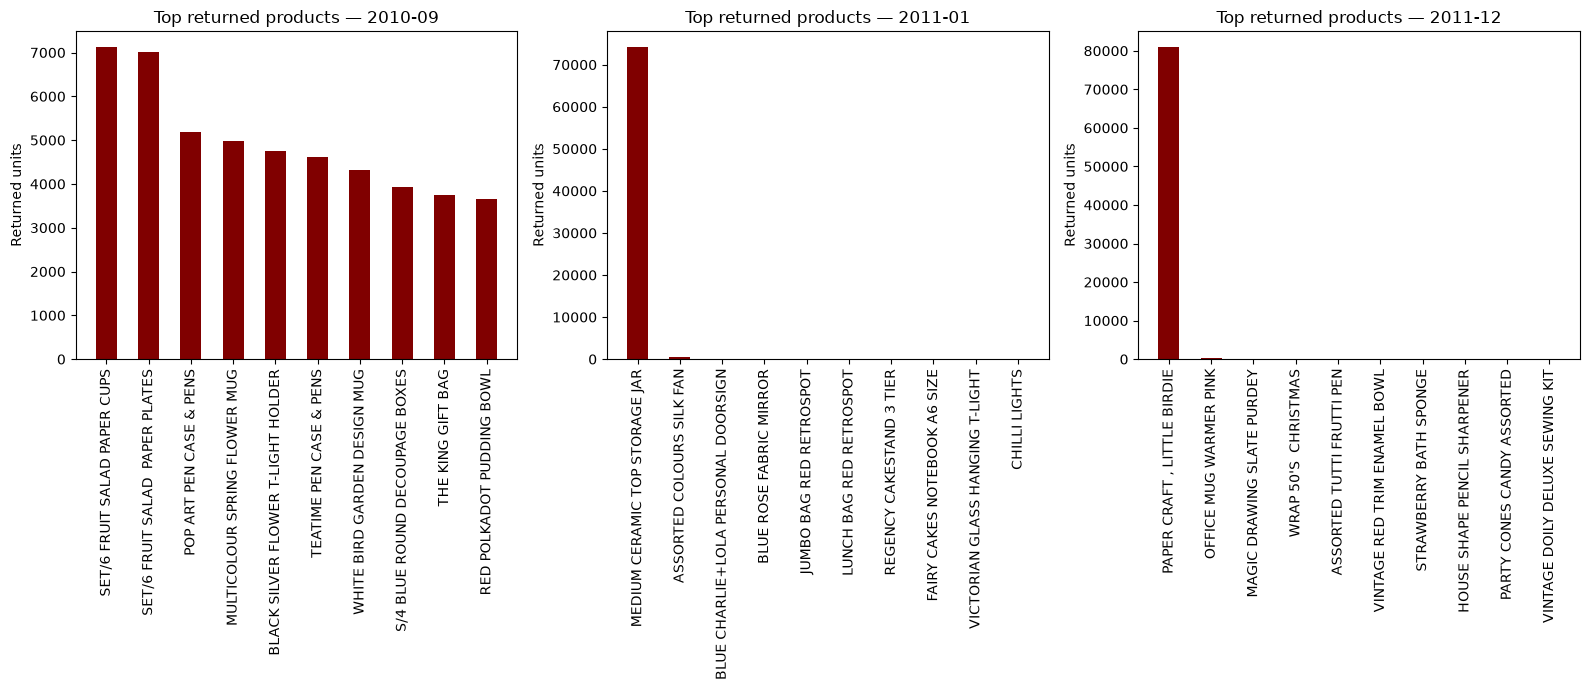

In [81]:
fig,ax = plt.subplots(1,3,figsize=(16,7))
top_10_prod = {}

for i,month in enumerate(months):
    df_returns["InvoiceDate"] = pd.to_datetime(df_returns["InvoiceDate"])
    df_sales["InvoiceDate"] = pd.to_datetime(df_sales["InvoiceDate"])

    mask_sales = df_sales["InvoiceDate"].dt.strftime("%Y-%m") == month
    mask_returns = df_returns["InvoiceDate"].dt.strftime("%Y-%m") == month

    df_month_sales = df_sales[mask_sales]
    df_month_returns = df_returns[mask_returns]

    top_10_prod[month] = (df_month_returns.groupby(["StockCode", "Description"], as_index=False)["Quantity"]
        .sum()
        .assign(Quantity=lambda x: x["Quantity"].abs())
        .sort_values("Quantity", ascending=False)
        .head(10))
    df_top = top_10_prod[month]

    ax[i].bar(df_top["Description"],df_top["Quantity"], width=0.5,color="maroon")
    ax[i].set_title(f"Top returned products — {month}")
    ax[i].set_ylabel("Returned units")
    ax[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

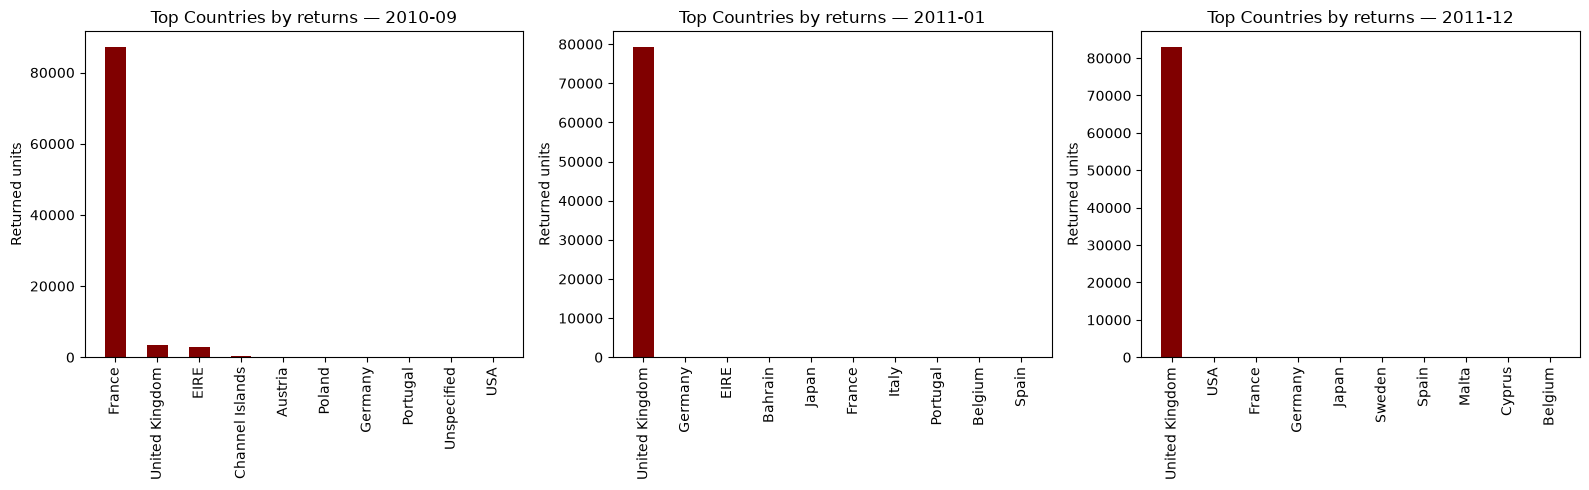

In [82]:
fig,ax = plt.subplots(1,3,figsize=(16,5))
top_10_country = {}

for i,month in enumerate(months):
    df_returns["InvoiceDate"] = pd.to_datetime(df_returns["InvoiceDate"])
    df_sales["InvoiceDate"] = pd.to_datetime(df_sales["InvoiceDate"])

    mask_sales = df_sales["InvoiceDate"].dt.strftime("%Y-%m") == month
    mask_returns = df_returns["InvoiceDate"].dt.strftime("%Y-%m") == month

    df_month_sales = df_sales[mask_sales]
    df_month_returns = df_returns[mask_returns]

    top_10_country[month] = (df_month_returns.groupby(["Country"], as_index=False)["Quantity"]
            .sum()
            .assign(Quantity=lambda x: x["Quantity"].abs())
            .sort_values("Quantity", ascending=False)
            .head(10))
    df_top = top_10_country[month]
    
    ax[i].bar(df_top["Country"],df_top["Quantity"], width=0.5,color="maroon")
    ax[i].set_title(f"Top Countries by returns — {month}")
    ax[i].set_ylabel("Returned units")
    ax[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

The three outlier months correspond to distinct events: September 2010 shows an unusually high number of returns across multiple products, predominantly from France, suggesting a possible issue with a specific distributor or customer. January 2011 and December 2011 are each driven by large-volume returns of a single product from the UK, likely reflecting individual bulk order cancellations rather than a systemic increase in return rate.
These months are retained in the analysis as they represent valid transactions, but are noted as exceptional events that disproportionately influence the monthly return rate.

In [43]:
sept_returns = df_ret_month[df_ret_month["year_month"]=="2010-09"]["return_volume"].item()
sept_returns_country = top_10_country["2010-09"]
sept_france = sept_returns_country[sept_returns_country["Country"]=="France"]["Quantity"].item()


jan_returns = df_ret_month[df_ret_month["year_month"]=="2011-01"]["return_volume"].item()
jan_returns_prod = top_10_prod["2011-01"]
jan_returns_country = top_10_country["2011-01"]
jan_uk = jan_returns_country[jan_returns_country["Country"]=="United Kingdom"]["Quantity"].item()
jan_prod = jan_returns_prod.iloc[0]["Quantity"].item()
jan_code = jan_returns_prod.iloc[0]["StockCode"]


dec_returns = df_ret_month[df_ret_month["year_month"]=="2011-12"]["return_volume"].item()
dec_returns_prod = top_10_prod["2011-12"]
dec_returns_country = top_10_country["2011-12"]
dec_uk = dec_returns_country[dec_returns_country["Country"]=="United Kingdom"]["Quantity"].item()
dec_prod = dec_returns_prod.iloc[0]["Quantity"].item()
dec_code = dec_returns_prod.iloc[0]["StockCode"]

In [44]:
print(f"SEPTEMBER 2010:\nTotal returns: {sept_returns}\nReturns from France: {sept_france} ({sept_france/sept_returns*100:.2f}% of total returns).\n")
print(f"JANUARY 2011:\nTotal returns: {jan_returns}\nReturns from UK: {jan_uk} ({jan_uk/jan_returns*100:.2f}% of total returns).\nReturns of product {jan_code}: {jan_prod} ({jan_prod/jan_returns*100:.2f}% of total returns.)\n")
print(f"DECEMBER 2011:\nTotal returns: {dec_returns}\nReturns from UK: {dec_uk} ({dec_uk/dec_returns*100:.2f}% of total returns).\nReturns of product {dec_code}: {dec_prod} ({dec_prod/dec_returns*100:.2f}% of total returns.)\n")

SEPTEMBER 2010:
Total returns: 94247
Returns from France: 87223 (92.55% of total returns).

JANUARY 2011:
Total returns: 79783
Returns from UK: 79307 (99.40% of total returns).
Returns of product 23166: 74215 (93.02% of total returns.)

DECEMBER 2011:
Total returns: 83538
Returns from UK: 83004 (99.36% of total returns).
Returns of product 23843: 80995 (96.96% of total returns.)



The analysis of outlier months reveals that the unusual peaks in return rate are not data anomalies but valid transactions, likely driven by issues with specific distributors or bulk order cancellations. For this reason, these records are retained in the analysis. However, when investigating returns by country and by product, results will be presented both including and excluding these transactions, in order to assess their influence on the overall findings.    
Specifically, when excluding these transactions, all returns from France will be removed in the month of September 2010, while for January and December of 2011 the specific products that were returned in bul will not be considered.

### 2.5.2 Returns per Country

In [83]:
q_country_ret = """
    SELECT 
    s.Country,
    s.sales_volume,
    COALESCE(r.return_volume, 0) AS return_volume,
    ROUND(COALESCE(r.return_volume, 0) * 100.0 / s.sales_volume, 2) AS return_rate
    FROM (
        SELECT Country, SUM(Quantity) AS sales_volume 
        FROM sales 
        GROUP BY Country
    ) s
    LEFT JOIN (
        SELECT Country, SUM(ABS(Quantity)) AS return_volume 
        FROM returns 
        GROUP BY Country
    ) r ON s.Country = r.Country
    ORDER BY return_volume DESC
    """



q_country_nopeaks = """
    SELECT 
    s.Country,
    s.sales_volume,
    COALESCE(r.return_volume, 0) AS return_volume,
    ROUND(COALESCE(r.return_volume, 0) * 100.0 / s.sales_volume, 2) AS return_rate
    FROM (
        SELECT Country, SUM(Quantity) AS sales_volume 
        FROM sales
        WHERE NOT ((strftime('%Y-%m', InvoiceDate) = '2010-09' AND Country = 'France')
            OR (strftime('%Y-%m', InvoiceDate) = '2011-01' AND StockCode = '23166')
            OR (strftime('%Y-%m', InvoiceDate) = '2011-12' AND Country = '23843'))
        GROUP BY Country
    ) s
    LEFT JOIN (
        SELECT Country, SUM(ABS(Quantity)) AS return_volume
        FROM returns 
        WHERE NOT ((strftime('%Y-%m', InvoiceDate) = '2010-09' AND Country = 'France')
                    OR (strftime('%Y-%m', InvoiceDate) = '2011-01' AND StockCode = '23166')
                    OR (strftime('%Y-%m', InvoiceDate) = '2011-12' AND Country = '23843'))
        GROUP BY Country
    ) r ON s.Country = r.Country
    ORDER BY return_volume DESC
    """

df_country_ret = pd.read_sql(q_country_ret, engine)
df_country_nopeaks = pd.read_sql(q_country_nopeaks, engine)


In [84]:
tot_sales = df_country_ret["sales_volume"].sum()
tot_returns = df_country_ret["return_volume"].sum()
tot_sales_nopeaks = df_country_nopeaks["sales_volume"].sum()
tot_returns_nopeaks = df_country_nopeaks["return_volume"].sum()

df_country_ret["sales_pct"]=(df_country_ret["sales_volume"]/tot_sales)*100
df_country_ret["returns_pct"]=(df_country_ret["return_volume"]/tot_returns)*100
df_country_nopeaks["sales_pct"]=(df_country_nopeaks["sales_volume"]/tot_sales_nopeaks)*100
df_country_nopeaks["returns_pct"]=(df_country_nopeaks["return_volume"]/tot_returns_nopeaks)*100

Text(0, 0.5, '% of Total Returns')

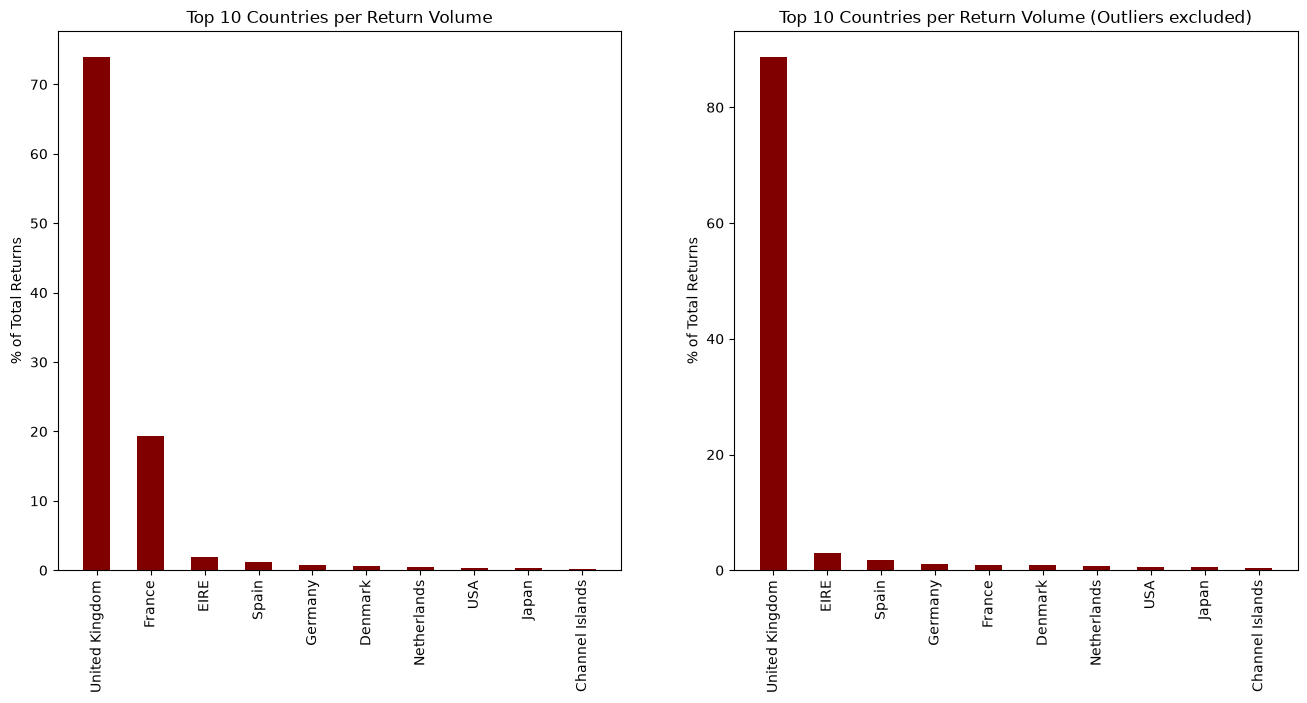

In [69]:
fig,ax = plt.subplots(1,2,figsize=(16,7))

ax[0].bar(df_country_ret["Country"][:10], df_country_ret["returns_pct"][:10], width=0.5, color="maroon")
ax[0].tick_params(axis='x', rotation=90)
ax[0].set_title("Top 10 Countries per Return Volume")
ax[0].set_ylabel("% of Total Returns")

ax[1].bar(df_country_nopeaks["Country"][:10], df_country_nopeaks["returns_pct"][:10], width=0.5, color="maroon")
ax[1].tick_params(axis='x', rotation=90)
ax[1].set_title("Top 10 Countries per Return Volume (Outliers excluded)")
ax[1].set_ylabel("% of Total Returns")


In [86]:
df_country_ret[["Country","sales_pct","returns_pct"]].head()

,Country,sales_pct,returns_pct
0,United Kingdom,82.030282,73.956044
1,France,2.415308,19.300038
2,EIRE,3.002268,1.952794
3,Spain,0.446380,1.205798
4,Germany,1.991529,0.706162


In [87]:
df_country_nopeaks[["Country","sales_pct","returns_pct"]].head()

,Country,sales_pct,returns_pct
0,United Kingdom,81.961255,88.705591
1,EIRE,3.024165,2.982024
2,Spain,0.449635,1.841320
3,Germany,2.006054,1.078348
4,France,2.370891,0.996076


Ase expected, the highest volume of returns comes from the United Kingdom, which is a direct consequence of the UK contributing to 82.03% of total sales. This is confirmed by its low return rate of 2.98%, indicating that a very small portion of purchased products is returned.     
Although the UK was responsible for the majority of sales of January and December 2011, removing the outlier months from the analysis does not significantly influence its statistics. The strongest influence is instead on France, whose contribution to total returns drops from 19.03% to 0.99%, suggesting that the September 2010 peak in returns is not aligned with the common France trend in returns.       

For a more comprehensive understanding, let us also visualize the ranking by return rate.

In [88]:
df_country_ret.sort_values(by=["return_rate"], ascending=False, inplace=True)
df_country_nopeaks.sort_values(by=["return_rate"], ascending=False, inplace=True)

Text(0, 0.5, 'Return Rate (%)')

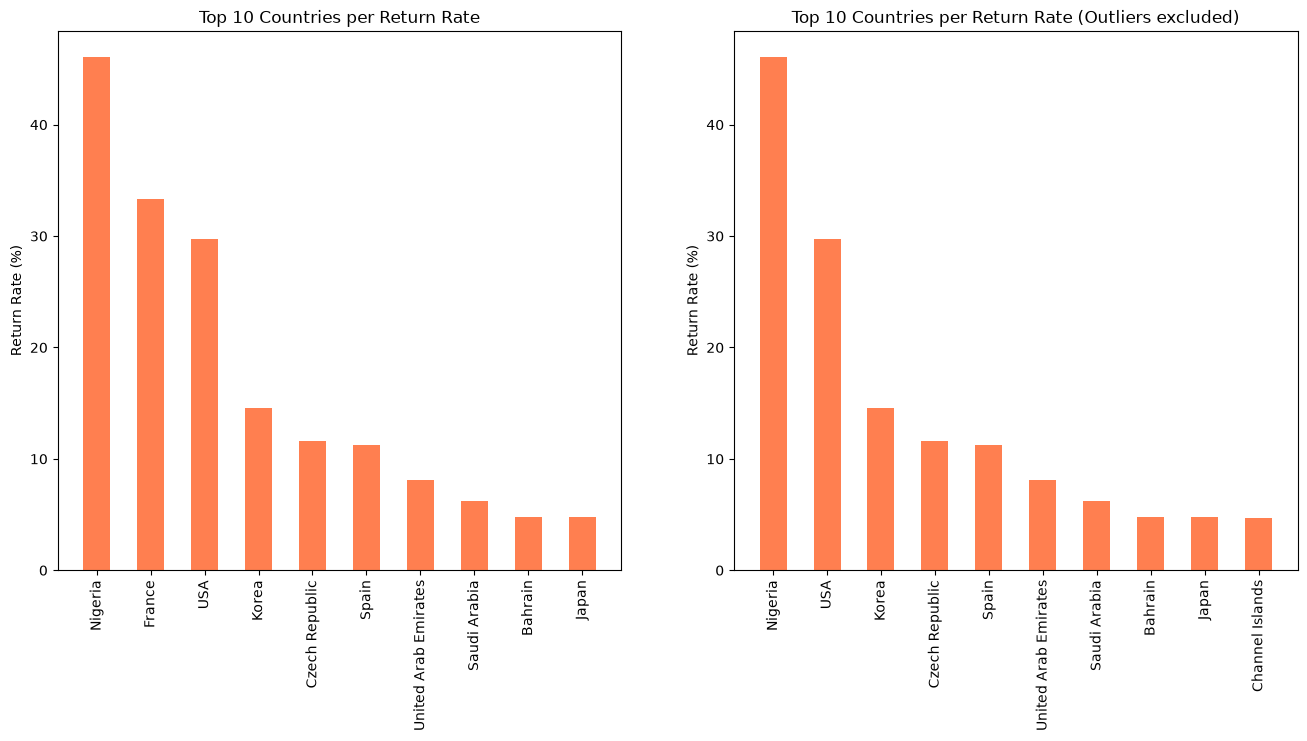

In [77]:
fig,ax = plt.subplots(1,2,figsize=(16,7))

ax[0].bar(df_country_ret["Country"][:10], df_country_ret["return_rate"][:10], width=0.5, color="coral")
ax[0].tick_params(axis='x', rotation=90)
ax[0].set_title("Top 10 Countries per Return Rate")
ax[0].set_ylabel("Return Rate (%)")

ax[1].bar(df_country_nopeaks["Country"][:10], df_country_nopeaks["return_rate"][:10], width=0.5, color="coral")
ax[1].tick_params(axis='x', rotation=90)
ax[1].set_title("Top 10 Countries per Return Rate (Outliers excluded)")
ax[1].set_ylabel("Return Rate (%)")


In [90]:
df_country_ret[["Country","sales_volume", "return_volume","return_rate"]].head()

,Country,sales_volume,return_volume,return_rate
26,Nigeria,102,47,46.08
1,France,270582,90274,33.36
7,USA,5259,1564,29.74
20,Korea,700,102,14.57
22,Czech Republic,670,78,11.64


In [89]:
df_country_nopeaks[["Country","sales_volume", "return_volume","return_rate"]].head()

,Country,sales_volume,return_volume,return_rate
26,Nigeria,102,47,46.08
7,USA,5259,1564,29.74
20,Korea,700,102,14.57
22,Czech Republic,670,78,11.64
2,Spain,50007,5640,11.28


In [91]:
df_country_nopeaks[df_country_nopeaks["Country"]=="France"][["Country","sales_volume", "return_volume","return_rate"]]

,Country,sales_volume,return_volume,return_rate
4,France,263683,3051,1.16


The country with highest return rate is Nigeria, with a 46.08% return rate — meaning that almost half of the purchased items is returned. The country has, however, a negligible impact on revenue loss for the company, due to its extremely low sales volume.

Removing the outlier transactions significantly affects the country rankings by return rate. The most notable case is France: including all transactions, France has an overall return rate of 33.36% — meaning more than a third of all purchased items are returned — and accounts for 19.3% of total returns, placing it among the highest-return countries. However, excluding the September 2010 peak, the return rate for France drops to 1.16%, with a contribution of just 0.99% to total returns.

This confirms that the September 2010 spike was an isolated event specific to French orders, rather than a structural pattern in French customer behaviour.

## what is the country that contribute

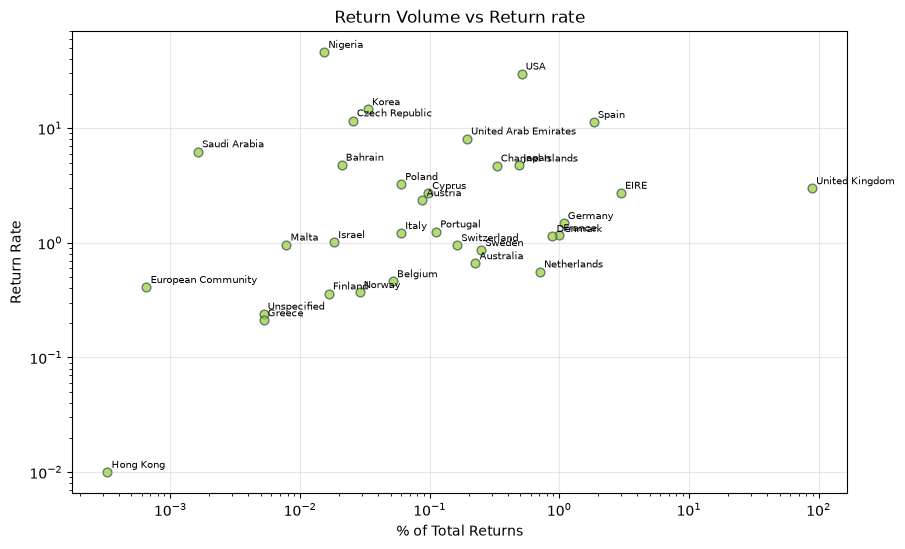

In [95]:
plt.figure(figsize=(10,6))
plt.scatter(
    df_country_nopeaks["returns_pct"],
    df_country_nopeaks["return_rate"],
    color="yellowgreen",
    alpha=0.7,
    edgecolor="darkslategrey",
    s=40)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("% of Total Returns")
plt.ylabel("Return Rate")
plt.title("Return Volume vs Return rate")
plt.grid(alpha=0.3)

for _, row in df_country_nopeaks.iterrows():
    plt.annotate(row["Country"], 
                 xy=(row["returns_pct"], row["return_rate"]),
                 fontsize=7,
                 xytext=(3, 3),
                 textcoords="offset points")


### 2.5.3 Returns per product